#Homework 4: Evaluation Metrics for Classification

##Dataset

In [2]:
!wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv

--2025-10-21 17:14:25--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 80876 (79K) [text/plain]
Saving to: ‘course_lead_scoring.csv’

course_lead_scoring 100%[===================>]  78.98K  --.-KB/s    in 0.04s   

2025-10-21 17:14:26 (1.78 MB/s) - ‘course_lead_scoring.csv’ saved [80876/80876]



##Подготовка данных
- Проверьте, представлены ли в характеристиках отсутствующие значения.
- Если имеются пропущенные значения:
  * Для категориальных признаков замените на «NA».
  * Для числовых характеристик замените на 0.0

Разделите данные на три части: обучающую/валидирующую/тестовую с распределением 60%/20%/20%. train_test_splitДля этого используйте функциюrandom_state=1

In [3]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [21]:
path = "/content/course_lead_scoring.csv"
df = pd.read_csv(path)
df.sample(3, random_state=42)

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
892,social_media,manufacturing,2,56070.0,self_employed,middle_east,2,0.23,1
1106,NaN,other,1,78409.0,NaN,australia,4,0.79,0
413,referral,manufacturing,2,66206.0,employed,australia,3,0.30,1


In [22]:
print(df.isna().sum())
df.info()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               1334 non-null   object 
 1   industry                  1328 non-null   object 
 2   number_of_courses_viewed  1462 non-null   int64  
 3   annual_income             1281 non-null   float64
 4   employment_status         1362 non-null   object 
 5   location                  1399 non-null   object 
 6   interaction_count         1462 non-null   int64  
 7   lead_score                1462 non-null   float64
 8   converted                 1462 non-nul

In [23]:
# List of numerical and categorical features
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(include="object").columns.tolist()

# Fill missing values
df[numerical_features] = df[numerical_features].fillna(0)
df[categorical_features] = df[categorical_features].fillna("NA")
print(df.isna().sum())

lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64


In [24]:
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NA,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NA,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [33]:
df.shape

(1462, 9)

In [36]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [31]:
target = "converted"
features = numerical_features + categorical_features
features.remove(target)

# Training set
X_train = df_train[features].reset_index(drop=True)
y_train = df_train[target].reset_index(drop=True)

# Validation set
X_val = df_val[features].reset_index(drop=True)
y_val = df_val[target].reset_index(drop=True)

# Test set
X_test = df_test[features].reset_index(drop=True)
y_test = df_test[target].reset_index(drop=True)

##Вопрос 1: Важность функции ROC AUC
ROC AUC также можно использовать для оценки важности признаков числовых переменных.

Давайте сделаем это

- Для каждой числовой переменной используйте ее в качестве оценки (т.е. прогноза) и вычислите AUC, используя yпеременную в качестве истинного значения.
- Используйте для этого обучающий набор данных.

Если ваша AUC < 0,5, инвертируйте эту переменную, поставив «-» перед ней.

(например -df_train['balance'])

AUC может опускаться ниже 0,5, если переменная отрицательно коррелирует с целевой переменной. Направление корреляции можно изменить, изменив знак этой переменной на отрицательный — тогда отрицательная корреляция станет положительной.

Какая числовая переменная (из следующих 4) имеет самую высокую AUC?

- lead_score
- number_of_courses_viewed
- interaction_count
- annual_income

In [37]:
numerical = numerical_features.copy()
numerical.remove(target)
print(numerical)

['number_of_courses_viewed', 'annual_income', 'interaction_count', 'lead_score']


In [39]:
from sklearn.metrics import roc_auc_score

In [44]:
for feat in numerical:
    auc = roc_auc_score(y_train, X_train[feat])
    if auc < 0.5:
        auc = roc_auc_score(y_train, -X_train[feat])
    print(f"{feat:<25}| AUC: {auc:.3f}")

number_of_courses_viewed | AUC: 0.764
annual_income            | AUC: 0.552
interaction_count        | AUC: 0.738
lead_score               | AUC: 0.614


##Вопрос 2: Обучение модели
Примените горячее кодирование DictVectorizerи обучите логистическую регрессию со следующими параметрами:

``` LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)```

Какова площадь под кривой (AUC) этой модели в проверочном наборе данных? (округлить до 3 цифр)

- 0,32
- 0,52
- 0,72
- 0,92

In [45]:
dv = DictVectorizer(sparse=False)

X_train = dv.fit_transform(X_train.to_dict(orient="records"))
X_val = dv.transform(X_val.to_dict(orient="records"))

X_train.shape, X_val.shape

((876, 31), (293, 31))

In [46]:
# Logistic Regression
model = LogisticRegression(solver="liblinear", C=1.0, max_iter=1_000)
model.fit(X_train, y_train)

# Validation set predictions
y_pred = model.predict_proba(X_val)[:, 1]

# AUC score
auc = roc_auc_score(y_val, y_pred)
print(f"Validation set AUC: {auc:.3f}")

Validation set AUC: 0.817


##Вопрос 3: Точность и полнота
Теперь давайте вычислим точность и полноту нашей модели.

- Оценить модель по всем порогам от 0,0 до 1,0 с шагом 0,01.
- Для каждого порога вычислите точность и полноту.
- Расположите их

На каком пороге пересекаются кривые точности и полноты?

- 0,145
- 0,345
- 0,545
- 0,745

In [49]:
from sklearn.metrics import precision_score, recall_score

In [50]:
# Thresholds
thresholds = np.linspace(start=0.0, stop=1.0, num=101)

# Scores
scores = []

# Evaluate thresholds
for t in thresholds:
    # Apply threshol to get binary prediction
    y_val_binary = (y_pred >= t).astype(int)

    # Calculate Precision and Recall
    p = precision_score(y_val, y_val_binary, zero_division=0)
    r = recall_score(y_val, y_val_binary)

    scores.append((t, p, r))

df_scores = pd.DataFrame(scores, columns=["threshold", "precision", "recall"])

# Absolute difference between precision and recall
df_scores["pr_diff"] = np.abs(df_scores["precision"] - df_scores["recall"])

# Find the threshold where this difference is minimal
intersection_threshold = (
    df_scores.query("precision != 0 & recall != 0")
    .sort_values(by="pr_diff")
    .head(1)["threshold"]
    .values[0]
)

print(f"Intersection threshold: {intersection_threshold:.3f}")

Intersection threshold: 0.640


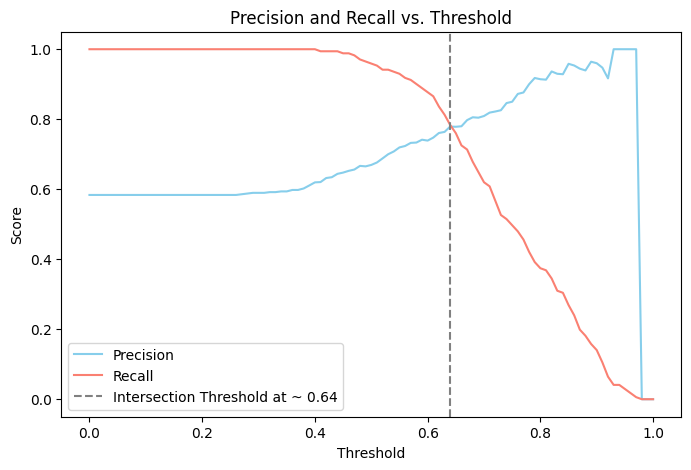

In [51]:
# Precision and Recall plot
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=df_scores, x="threshold", y="precision", label="Precision", color="skyblue"
)

sns.lineplot(data=df_scores, x="threshold", y="recall", label="Recall", color="salmon")

plt.axvline(
    x=intersection_threshold,
    color="gray",
    linestyle="--",
    label=f"Intersection Threshold at ~ {intersection_threshold:.2f}",
)

plt.grid(False)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs. Threshold")

plt.legend()
plt.show()

##Вопрос 4: Оценка F1
Точность и полнота противоречат друг другу: когда одно растёт, другое падает. Поэтому их часто объединяют в оценку F1 — метрику, которая учитывает оба показателя.

Вот формула для вычисления F1:

$$F_1 = 2 \cdot \cfrac{P \cdot R}{P + R}$$

Где
П
это точность и
Р
это отзыв.

Давайте вычислим F1 для всех порогов от 0,0 до 1,0 с шагом 0,01.

При каком пороге F1 максимален?

- 0,14
- 0,34
- 0,54
- 0,74

In [52]:
df_scores["f1_score"] = (
    2
    * (df_scores.precision * df_scores.recall)
    / (df_scores.precision + df_scores.recall)
)

best_f1_threshold = df_scores.iloc[np.argmax(df_scores.f1_score)]["threshold"]

print(f"The best threshold based on F1 score is: {best_f1_threshold:.3f}")

The best threshold based on F1 score is: 0.570


##Вопрос 5: 5-кратное резюме
Используйте KFoldкласс из Scikit-Learn для оценки нашей модели на 5 различных свертках:

``` KFold(n_splits=5, shuffle=True, random_state=1)```

- Перебирать различные складкиdf_full_train
- Разделить данные на обучающие и проверочные
- Обучите модель на train с этими параметрами:LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
- Используйте AUC для оценки модели при валидации

Насколько велико стандартное отклонение оценок в разных сверткаx?

- 0,0001
- 0,006
- 0,06
- 0,36

In [54]:
from sklearn.model_selection import KFold

In [55]:
# Initialize k-fold for cross validation
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

auc_scores = []

# Cross Validation
for train_idx, val_idx in kfold.split(full_train_df):
    # Create train and validation sets for this fold
    df_train_fold = full_train_df.iloc[train_idx]
    df_val_fold = full_train_df.iloc[val_idx]

    # Get the target variable
    y_train_fold = df_train_fold[target].to_numpy()
    y_val_fold = df_val_fold[target].to_numpy()

    # One-hot enconding
    # Initialize and Fit the vectorizer
    dv_fold = DictVectorizer(sparse=False)

    X_train_fold = dv_fold.fit_transform(
        df_train_fold[features].to_dict(orient="records")
    )

    # Transform the validation data using the fitted vectorizer
    X_val_fold = dv_fold.transform(df_val_fold[features].to_dict(orient="records"))

    # Train the model
    model_fold = LogisticRegression(solver="liblinear", C=1.0, max_iter=1_000)
    model_fold.fit(X_train_fold, y_train_fold)

    # Get predictions and calculate AUC
    y_pred_fold = model_fold.predict_proba(X_val_fold)[:, 1]
    auc = roc_auc_score(y_val_fold, y_pred_fold)
    auc_scores.append(auc)

# Calculate the Standard Deviation of AUC
std_auc = np.std(auc_scores)

print(f"AUC scores per fold: {[round(s, 3) for s in auc_scores]}")
print(f"Standard Deviation: {std_auc:.4f}")

AUC scores per fold: [np.float64(0.806), np.float64(0.871), np.float64(0.775), np.float64(0.802), np.float64(0.856)]
Standard Deviation: 0.0358


##Вопрос 6: Настройка гиперпараметров
Теперь давайте используем 5-кратную перекрестную проверку, чтобы найти лучший параметр.C

- Переберите следующие Cзначения:[0.000001, 0.001, 1]
- Инициализируйте KFoldс теми же параметрами, что и ранее.
- Используйте следующие параметры для модели: ``` LogisticRegression(solver='liblinear', C=C, max_iter=1000) ```
- Вычислите средний балл, а также стандартное отклонение (округлите среднее значение и стандартное отклонение до трех десятичных знаков).

Какой Cвариант дает наилучший средний балл?

- 0,000001
- 0,001
- 1

Если у вас есть одинаковые результаты, выберите результат с наименьшим стандартным отклонением. Если же результаты всё ещё одинаковые, выберите результат с наименьшим стандартным отклонением C.

In [56]:
C_values = [0.000001, 0.001, 1.0]

# Initialize k-fold for cross validation
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

cv_results = {}

for C in C_values:
    auc_scores_fold = []

    # Cross Validation
    for train_idx, val_idx in kfold.split(full_train_df):
        # Create train and validation sets for this fold
        df_train_fold = full_train_df.iloc[train_idx]
        df_val_fold = full_train_df.iloc[val_idx]

        # Get the target variable
        y_train_fold = df_train_fold[target].to_numpy()
        y_val_fold = df_val_fold[target].to_numpy()

        # One-hot enconding
        # Initialize and Fit the vectorizer
        dv_fold = DictVectorizer(sparse=False)

        X_train_fold = dv_fold.fit_transform(
            df_train_fold[features].to_dict(orient="records")
        )

        # Transform the validation data using the fitted vectorizer
        X_val_fold = dv_fold.transform(df_val_fold[features].to_dict(orient="records"))

        # Train the model
        model_fold = LogisticRegression(solver="liblinear", C=C, max_iter=1_000)
        model_fold.fit(X_train_fold, y_train_fold)

        # Get predictions and calculate AUC
        y_pred_fold = model_fold.predict_proba(X_val_fold)[:, 1]
        auc = roc_auc_score(y_val_fold, y_pred_fold)
        auc_scores_fold.append(auc)

    # Calculate mean and std for this C
    mean_auc = np.mean(auc_scores_fold)
    std_auc = np.std(auc_scores_fold)

    cv_results[C] = {"mean_auc": mean_auc, "std_auc": std_auc}

    print(f"C = {C:<8.6f} | Mean AUC: {mean_auc:.3f} | Std: {std_auc:.3f}")

C = 0.000001 | Mean AUC: 0.560 | Std: 0.024
C = 0.001000 | Mean AUC: 0.867 | Std: 0.029
C = 1.000000 | Mean AUC: 0.822 | Std: 0.036


In [57]:
best_C = None
best_mean_auc = -1
best_std = float("inf")

for C, scores in cv_results.items():
    mean_auc = scores["mean_auc"]
    std_auc = scores["std_auc"]

    if mean_auc > best_mean_auc:
        best_mean_auc = mean_auc
        best_std = std_auc
        best_C = C
    elif mean_auc == best_mean_auc:
        if std_auc < best_std:  # Tie-breaker: lower std
            best_std = std_auc
            best_C = C

print(f"\nBest C value: {best_C}")


Best C value: 0.001


In [60]:
print(
    f"{best_C} {cv_results[best_C]['mean_auc']:.3f} {cv_results[best_C]['std_auc']:.3f}"
)

0.001 0.867 0.029
